Now we will try to move from Gaussian 2D to bimodal by applying Rotation to the coordinates. This is just to get to bimodal using a function. 

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import math

In [37]:
class Rotation(nn.Module):
    def __init__(self, theta=0.7):
        super().__init__()
        self.theta = theta % (2 * math.pi)

    def forward(self, x):
        c, s = torch.cos(torch.tensor(self.theta)), torch.sin(torch.tensor(self.theta))
        R = torch.tensor([[c, -s],
                          [s,  c]])
        return x @ R.T

    def inverse(self, x):
        c, s = torch.cos(torch.tensor(self.theta)), torch.sin(torch.tensor(self.theta))
        R_inv = torch.tensor([[c, s],
                              [-s, c]])
        return x @ R_inv.T


What is a rotation matrix? https://www.cuemath.com/algebra/rotation-matrix/
We are just rotating the coordinate frames and then applying projection of them. Inverse is simply rotating it back and projecting. 

In [38]:
class Coupling(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.5))
        self.b = nn.Parameter(torch.tensor(1.0))

    def forward(self, z):
        x1 = z[:, 0]
        x2 = z[:, 1] + self.a * torch.tanh(self.b * z[:, 0])
        return torch.stack([x1, x2], dim=1)

    def inverse(self, x):
        z1 = x[:, 0]
        z2 = x[:, 1] - self.a * torch.tanh(self.b * x[:, 0])
        return torch.stack([z1, z2], dim=1)

Please refer to this: https://github.com/SarveshAngadi09/Robotics-CV/blob/main/NormalizingFlows/Normalizing_flows2DGaussian.ipynb

**x2 = z2 + a.(tanh(b.z1))**

In [77]:
flow = Coupling()
rot = Rotation(theta=0.6)

with torch.no_grad():
    z = torch.randn(5000, 2)
    x = flow.forward(z)
    x = rot.forward(x)

First apply the transformation function and then rotate the transformed function. 

0.6


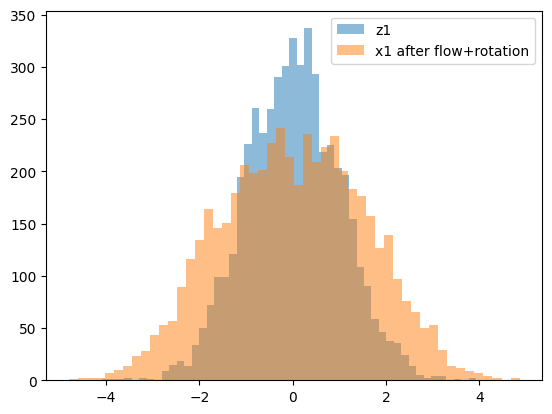

In [78]:
print(rot.theta)
plt.hist(z[:,1].numpy(), bins=50, alpha=0.5, label="z1")
plt.hist(x[:,1].numpy(), bins=50, alpha=0.5, label="x1 after flow+rotation")
plt.legend()
plt.show()

It is close to bimodal but still not a bimodal. Let us try something better. 